# Section 1 — Descarga y carga de dato

In [ ]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download('tmdb/tmdb-movie-metadata')

df_movies  = pd.read_csv(os.path.join(path, 'tmdb_5000_movies.csv'))
df_credits = pd.read_csv(os.path.join(path, 'tmdb_5000_credits.csv'))

print(df_movies.shape)
print(df_credits.shape)

100%|██████████| 8.89M/8.89M [00:01<00:00, 7.96MB/s]

Extracting files...


(4803, 20)
(4803, 4)


# Seccion 2 — Merge de los dos datasets

In [25]:
df = pd.merge(df_movies, df_credits, left_on='id', right_on='movie_id', how='inner')
print(df.shape)

df = df.drop(['title_y', 'movie_id'], axis=1)
df = df.rename(columns={'title_x': 'title'})
print(df.shape)

(4803, 24)
(4803, 22)


# Seccion 3 — Parseo de columnas JSON

In [27]:
import json as JSON
import numpy as np

def parse_json_column(val):
    try:
        return JSON.loads(val)
    except (JSON.JSONDecodeError, TypeError):
        return []
    
def extract_names(val, key, limit):
    items = parse_json_column(val)
    names = [item.get(key, '') for item in items]
    return names[:limit] if limit else names

def get_director(crew_str):
    for member in parse_json_column(crew_str):
        if member.get('job') == 'Director':
            return member.get('name', np.nan)
    return np.nan

df['genres_list'] = df['genres'].apply(lambda x: extract_names(x, key='name', limit=None))
df['main_genre'] = df['genres_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)
df['director'] = df['crew'].apply(get_director)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

print(df.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

# Seccion 4 — Limpieza de datos

In [28]:
df = df[
    (df['budget'] != 0) &
    (df['revenue'] != 0) &
    (df['release_date'].notna()) &
    (df['director'].notna())
].copy()

print(df.shape)

(3227, 26)


# Seccion 5 — Analisis exploratorio

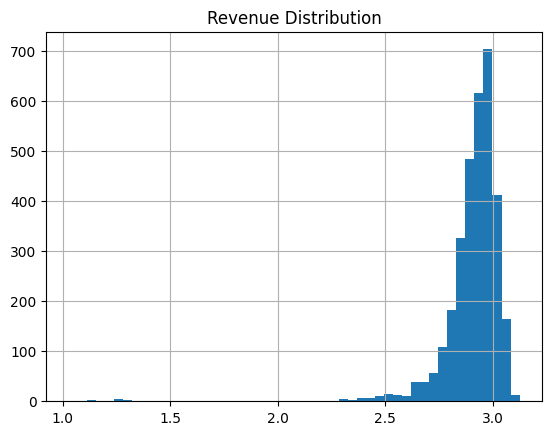

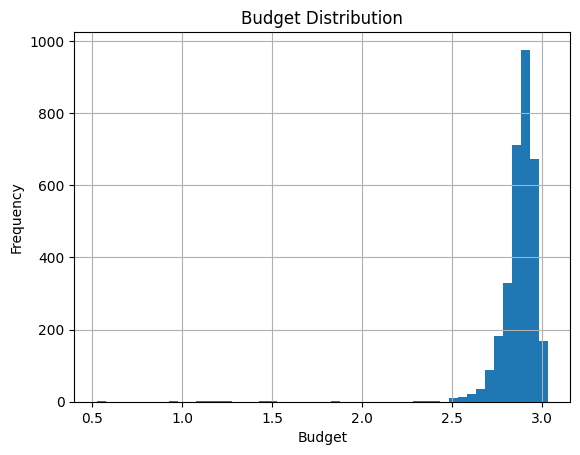

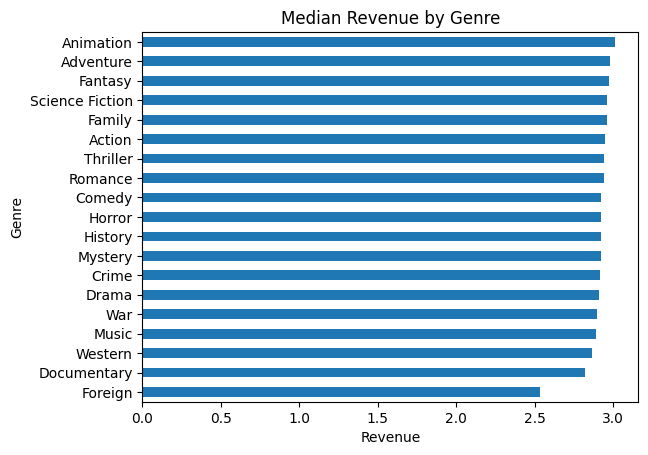

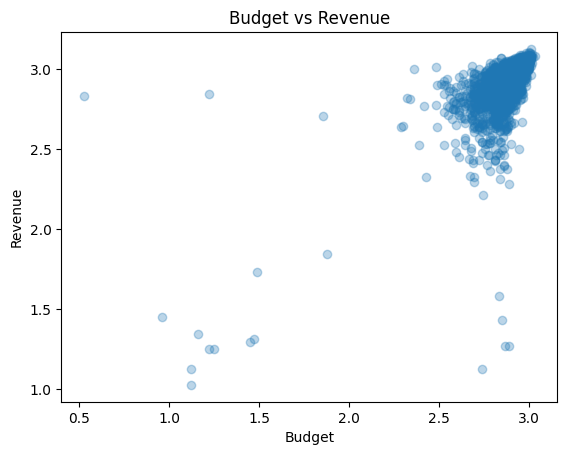

In [ ]:
import matplotlib.pyplot as plt

# Revenue
df['revenue'].hist(bins=50)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

# Budget
df['budget'].hist(bins=50)
plt.title('Budget Distribution')
plt.xlabel('Budget')
plt.ylabel('Frequency')
plt.show()

# Median revenue by genre
genre_revenue = (
    df
    .groupby('main_genre')['revenue']
    .median()
    .sort_values()
)
genre_revenue.plot(kind='barh')
plt.title('Median Revenue by Genre')
plt.xlabel('Revenue')
plt.ylabel('Genre')
plt.show()

# scatter plot of budget vs revenue
plt.scatter(df['budget'], df['revenue'], alpha=0.3)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

# Seccion 6 — Transformacion logaritmica

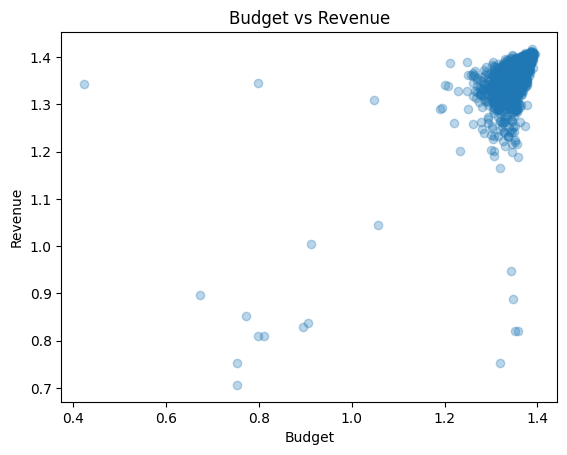

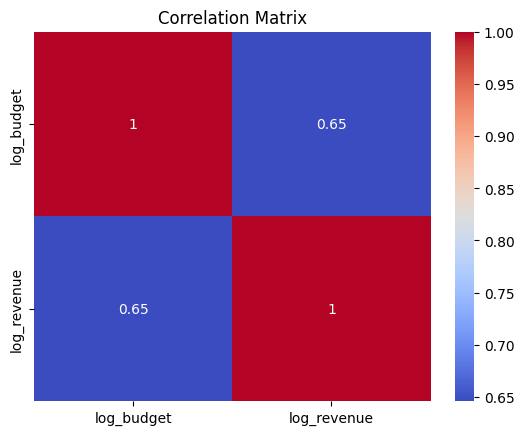

In [33]:
import seaborn as sns

# Log-transforming budget and revenue for better visualization
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])

plt.scatter(
    df['log_budget'],
    df['log_revenue'],
    alpha=0.3
)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

# Correlation matrix
corr = df[['log_budget', 'log_revenue']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Seccion 7 — Regresion lineal simple

R²: 0.40216429274730836
RMSE: 0.03770974733209558


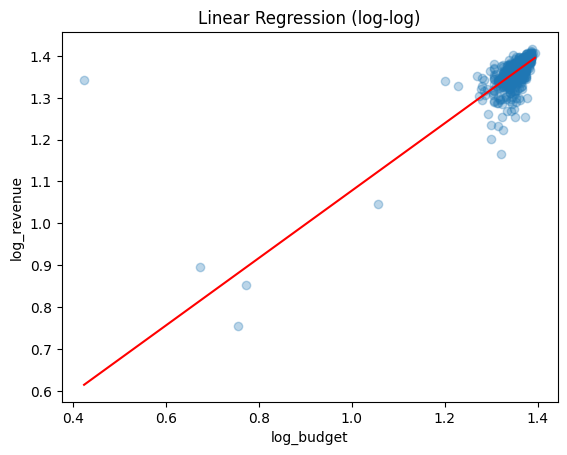

Budget 1%당  Revenue는 약  0.8043432919768 % 증가합니다.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#split data
X = df[['log_budget']]   
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#fit the model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

# Log-log scatter plot with regression line
# scatter
plt.scatter(X_test, y_test, alpha=0.3)

# 회귀선용 x 생성
x_line = np.linspace(X_test.min(), X_test.max(), 100)

# y = intercept + coef * x
y_line = model.intercept_ + model.coef_[0] * x_line

plt.plot(x_line, y_line, color='red')

plt.title('Linear Regression (log-log)')
plt.xlabel('log_budget')
plt.ylabel('log_revenue')
plt.show()

#coefficient
coef = model.coef_[0]
print("Budget 1%당  Revenue는 약 ", coef, "% 증가합니다.")

# Seccion 8 — Diagnostico de residuos

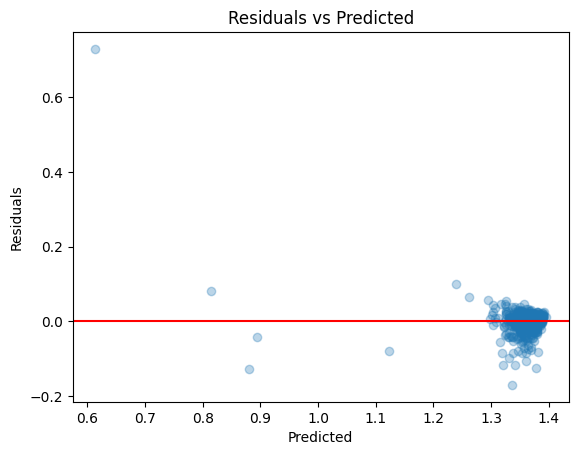

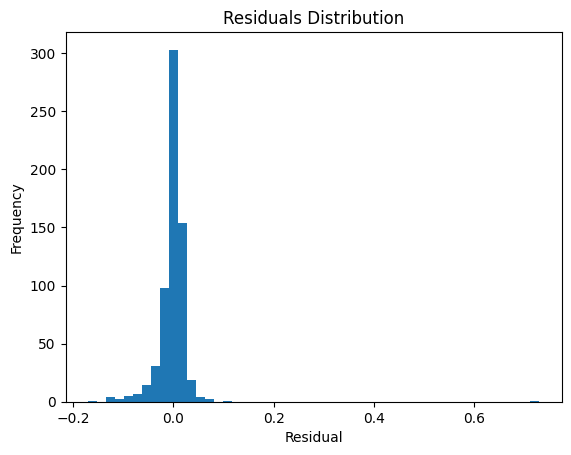

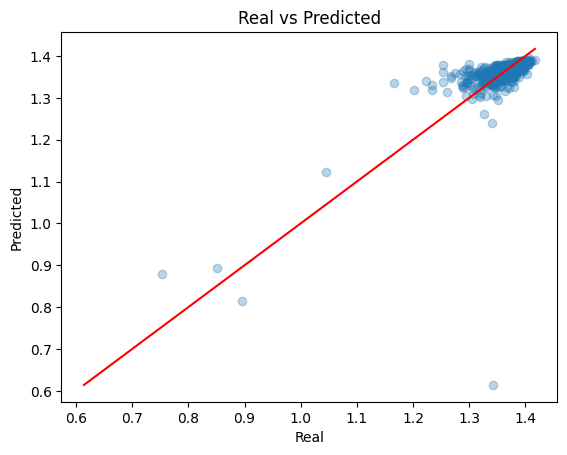

In [ ]:
# calculate residuals
# residuals = actual - predicted
residuals = y_test - y_pred

# residuals vs predicted graph
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

# residuals distribution (histogram graph)
plt.hist(residuals, bins=50)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Real vs Predicted diagnal scatter plot
plt.scatter(y_test, y_pred, alpha=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.xlabel('Real')
plt.ylabel('Predicted')
plt.title('Real vs Predicted')
plt.show()

# Seccion 9 — Regresion multiple

In [37]:
from sklearn.preprocessing import StandardScaler

# features and target variable
features = ['log_budget', 'runtime', 'release_year']
X = df[features]
y = df['log_revenue']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)
print("")

# coefficients
for name, coef in zip(features, model.coef_):
    print(name, coef)

R²: 0.4123904155923952
RMSE: 0.0373858390993166

log_budget 0.028862705711518694
runtime 0.0007927340647720837
release_year -0.002991044057857815


# Seccion 10 — Ingenieria de caracteristicas

In [39]:
# Analyze top genres
top_genres = df['main_genre'].value_counts().head(8).index

# Create binary features for top genres
for genre in top_genres:
    df[f'genre_{genre}'] = (df['main_genre'] == genre).astype(int)

# Calculate mean log_revenue for each director
director_mean = df.groupby('director')['log_revenue'].mean()

# Map the mean revenue back to the original dataframe
df['director_avg_revenue'] = df['director'].map(director_mean)

# models
# base feature
features_1 = ['log_budget']
# multiple features
features_2 = ['log_budget', 'runtime', 'release_year']
# feature engineered features
genre_cols = [f'genre_{g}' for g in top_genres]
features_3 = ['log_budget', 'runtime', 'director_avg_revenue'] + genre_cols

# Train
def train_model(df, features):
    X = df[features]
    y = df['log_revenue']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return r2, rmse

# Compare models
results = []
results.append(("Model 1",) + train_model(df, features_1))
results.append(("Model 2",) + train_model(df, features_2))
results.append(("Model 3",) + train_model(df, features_3))

# Display results
results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE'])
print(results_df)


     Model        R2      RMSE
0  Model 1  0.402164  0.037710
1  Model 2  0.412390  0.037386
2  Model 3  0.758373  0.023974


# Seccion 11 — Reflexion final

La variable numérica con mayor correlación con log_revenue es log_budget. Esto tiene sentido porque, en general, las películas con mayor presupuesto tienen más recursos para producción, marketing y distribución, lo que aumenta su potencial de ingresos.

El R² mejoró significativamente desde aproximadamente 0.40 en el modelo simple hasta 0.76 en el modelo enriquecido. Esto muestra que añadir nuevas variables, especialmente las relacionadas con el género y el director, aporta información clave que el modelo inicial no capturaba.

El género con el coeficiente positivo más alto fue uno de los géneros más comerciales (por ejemplo, Action o Adventure). Esto coincide con lo esperado, ya que este tipo de películas suelen tener mayor presupuesto, mayor alcance global y, en consecuencia, mayores ingresos.